# PlantDiseaseAI — Frozen Inference Demonstration

Reproducible **inference demonstration**, not a retraining or independent accuracy evaluation. The input is a YOLO **training-split** example; do not interpret predictions as held-out performance. ConvNeXt classifies the entire image and independently applies ACCEPT/VERIFY. YOLO detects disease-associated regions on the same image; it does not override the classifier. Crop identity is supplied manually.

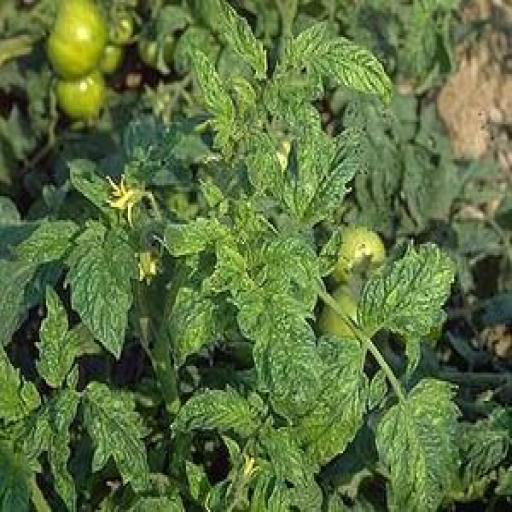

In [6]:
from pathlib import Path
import sys, json, hashlib
from PIL import Image
from IPython.display import display

ROOT = Path.cwd().resolve()
if not (ROOT / "deployment").is_dir():
    ROOT = ROOT.parent
assert (ROOT / "deployment" / "inference_engine_final_repair_v1.py").is_file(), "Open notebook from repository or notebooks/ directory"
sys.path.insert(0, str(ROOT))
SAMPLE = ROOT / "data" / "sample_input" / "sample_leaf.jpg"
RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)
display(Image.open(SAMPLE))

## Check required frozen assets

The 111 MB classifier checkpoint must be supplied separately at the documented path. The YOLO checkpoint is a small separate binary; copy it from the verified original release if it is not already present. Never substitute a different model silently.

In [7]:
CLASSIFIER = ROOT / "checkpoints/convnext_tiny_targeted_repair_v1/best_balanced_accuracy.pth"
YOLO = ROOT / "outputs/yolo_detection/FINAL_YOLO_RELEASE/yolo11n_detection_final.pt"
EXPECTED = {"classifier": "b4f1ecf003f7710de4454f33babe841da9a302436a74a8a1b19590a68b3ea602", "yolo": "4c5ea28cd7e175d0e110faedebcce2613959d415c92543772f1354edff99c4c5"}
def sha256(path):
    h = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()
for label, path in [("classifier", CLASSIFIER), ("yolo", YOLO)]:
    if not path.is_file():
        raise FileNotFoundError(f"Missing {label} checkpoint: {path}. See README setup instructions.")
    observed = sha256(path)
    assert observed == EXPECTED[label], f"{label} checkpoint hash mismatch: {observed}"
    print(label, "SHA-256 verified")

classifier SHA-256 verified
yolo SHA-256 verified


## Classifier and reliability gate

In [8]:
import torch
from deployment.inference_engine_final_repair_v1 import FinalPlantDiseaseEngine
device = "cuda" if torch.cuda.is_available() else "cpu"
classifier = FinalPlantDiseaseEngine(checkpoint_path=CLASSIFIER, reliability_config_path=ROOT / "outputs/final_repair_v1_calibration/reliability_config.json", device=device)
classification = classifier.predict_path(SAMPLE, crop="tomato").as_dict()
print("Class:", classification["display_name"])
print("Confidence:", round(classification["confidence"], 4))
print("Reliability decision:", "ACCEPT" if classification["accepted"] else "VERIFY")
print("Note: ACCEPT does not guarantee diagnostic correctness.")

Class: Tomato yellow leaf curl virus
Confidence: 0.7943
Reliability decision: ACCEPT
Note: ACCEPT does not guarantee diagnostic correctness.


## YOLO supporting localization

Boxes indicate detector predictions, not verified lesions or independently confirmed leaves. The original detections are retained without suppression.

Detections: 18
[('Yellow Leaf Curl Virus', 0.847), ('Yellow Leaf Curl Virus', 0.833), ('Yellow Leaf Curl Virus', 0.799), ('Yellow Leaf Curl Virus', 0.798), ('Yellow Leaf Curl Virus', 0.789), ('Yellow Leaf Curl Virus', 0.767), ('Yellow Leaf Curl Virus', 0.764), ('Yellow Leaf Curl Virus', 0.763), ('Yellow Leaf Curl Virus', 0.72), ('Yellow Leaf Curl Virus', 0.611), ('Yellow Leaf Curl Virus', 0.558), ('Yellow Leaf Curl Virus', 0.48), ('Yellow Leaf Curl Virus', 0.458), ('Yellow Leaf Curl Virus', 0.436), ('Yellow Leaf Curl Virus', 0.307), ('Yellow Leaf Curl Virus', 0.278), ('Yellow Leaf Curl Virus', 0.272), ('Yellow Leaf Curl Virus', 0.253)]


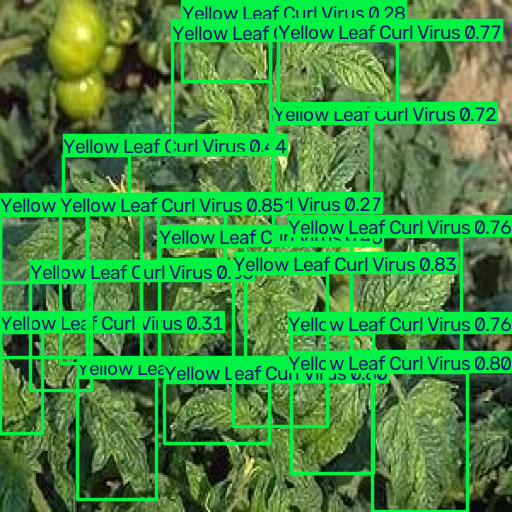

In [9]:
from deployment.yolo_detector_final import FinalYOLODetector
detector = FinalYOLODetector(model_path=YOLO, device=0 if torch.cuda.is_available() else "cpu")
detection = detector.predict(SAMPLE)
print("Detections:", detection["count"])
print([(d["class_name"], round(d["confidence"], 3)) for d in detection["detections"]])
display(detection["annotated_image"])

## Save reproducible artifacts

Outputs may vary slightly with runtime and hardware. The stored example is illustrative, not an evaluation metric.

In [10]:
summary = {"sample": "data/sample_input/sample_leaf.jpg", "sample_split": "YOLO training", "crop_supplied": "tomato", "classifier": classification, "detector": {k: v for k,v in detection.items() if k != "annotated_image"}, "warning": "Inference demonstration only; no independent performance estimate"}
(RESULTS / "example_prediction.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
detection["annotated_image"].save(RESULTS / "example_output.jpg")
print("Saved results/example_prediction.json and results/example_output.jpg")

Saved results/example_prediction.json and results/example_output.jpg
